# Amazon Review Sentiment Analysis

## 1. Introduction

This project performs binary sentiment classification on Amazon Alexa
product reviews. The goal is to use natural-language review text to
predict whether a review belongs to the positive or negative feedback
class.

# Importing Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Loading and Understanding Data

In [3]:


data = pd.read_csv("amazon_alexa.tsv", sep="\t")

data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [4]:
data.shape

(3150, 5)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [6]:
data.isnull().sum()


rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [7]:
data["feedback"].value_counts()

feedback
1    2893
0     257
Name: count, dtype: int64

In [8]:
data["rating"].value_counts().sort_index()

rating
1     161
2      96
3     152
4     455
5    2286
Name: count, dtype: int64

In [9]:
data = data.dropna(subset=["verified_reviews"])

data.shape

(3149, 5)

# Exploratory Data Analysis

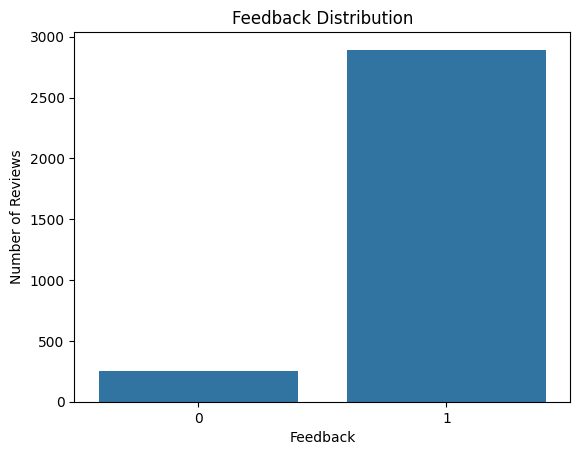

In [10]:


sns.countplot(x="feedback", data=data)

plt.title("Feedback Distribution")
plt.xlabel("Feedback")
plt.ylabel("Number of Reviews")
plt.show()

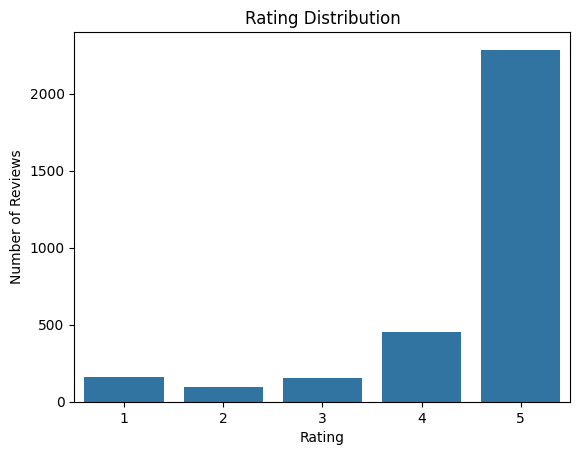

In [11]:
sns.countplot(x="rating", data=data)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [12]:
pd.crosstab(data["rating"], data["feedback"])

feedback,0,1
rating,,
1,161,0
2,95,0
3,0,152
4,0,455
5,0,2286


In [13]:
data[["verified_reviews", "rating", "feedback"]].head(10)

,verified_reviews,rating,feedback
0,Love my Echo!,5,1
1,Loved it!,5,1
2,"Sometimes while playing a game, you can answer...",4,1
3,I have had a lot of fun with this thing. My 4 ...,5,1
4,Music,5,1
5,I received the echo as a gift. I needed anothe...,5,1
6,"Without having a cellphone, I cannot use many ...",3,1
7,I think this is the 5th one I've purchased. I'...,5,1
8,looks great,5,1
9,Love it! I’ve listened to songs I haven’t hear...,5,1


In [14]:
data["verified_reviews"].sample(10, random_state=42).tolist()

['Love it, we are still learning the capabilities, having a lot of fun.',
 "I was hesitant to buy the echo because I have the echo Dot and it seems good enough. The echo is the same except the sound quality, which I really didn't feel I needed. However, I am so glad I got it. What a difference! The sound really is far superior to the Echo Dot! Now I can listen to The Greatest Showman with a little more power!",
 'Invasive and scared the crap out of me for speaking when it was not spoken to! CREAPY AF',
 'We love the echo spot I use it on my nightstand for alarm clock and play iHeartRadio radio while getting dressed!!',
 'Fun and  information.  No dislikes  so far !! Like the convenience!!',
 'I am very pleased with the Fire Stick.',
 'Great addition to our Alexa family. Great video also.',
 "I haven't figured out how to make or receive calls.  Device tells me I need to register and I do not know what to do.",
 'Echo Dot and related devices are the best thing to come in a long time.',
 

# Duplicate Investigation


In [15]:
data["verified_reviews"].duplicated().sum()

np.int64(849)

In [16]:
duplicate_reviews = data[data["verified_reviews"].duplicated(keep=False)]

duplicate_reviews.groupby("verified_reviews")["feedback"].nunique().value_counts()

feedback
1    678
2      1
Name: count, dtype: int64

In [17]:
data["verified_reviews"] = data["verified_reviews"].str.strip()

data = data[data["verified_reviews"] != ""]

data.shape

(3070, 5)

In [18]:
print("Missing reviews:", data["verified_reviews"].isnull().sum())
print("Empty reviews:", (data["verified_reviews"] == "").sum())

Missing reviews: 0
Empty reviews: 0


In [19]:
data["verified_reviews"].duplicated().sum()

np.int64(771)

In [20]:
print(
    "Remaining duplicate reviews:",
    data["verified_reviews"].duplicated().sum()
)

Remaining duplicate reviews: 771


In [21]:
print(data["feedback"].value_counts())

print("\nClass percentages:")
print(data["feedback"].value_counts(normalize=True) * 100)

feedback
1    2833
0     237
Name: count, dtype: int64

Class percentages:
feedback
1    92.28013
0     7.71987
Name: proportion, dtype: float64


In [22]:
print("\nRating distribution:")
print(data["rating"].value_counts().sort_index())


Rating distribution:
rating
1     146
2      91
3     140
4     447
5    2246
Name: count, dtype: int64


# Deleting ML Data

In [23]:
X = data["verified_reviews"]
y = data["feedback"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3070,)
y shape: (3070,)


In [24]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2456
Testing samples: 614


In [25]:
stratify=y

In [26]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training class distribution:
feedback
1    92.263844
0     7.736156
Name: proportion, dtype: float64

Testing class distribution:
feedback
1    92.345277
0     7.654723
Name: proportion, dtype: float64


# TF-IDF

In [27]:


tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (2456, 5000)
Testing TF-IDF shape: (614, 5000)


In [28]:
tfidf.fit_transform(X_train)

<2456x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 75759 stored elements in Compressed Sparse Row format>

In [29]:
tfidf.transform(X_test)

<614x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 17582 stored elements in Compressed Sparse Row format>

In [30]:


lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [31]:
y_pred = lr_model.predict(X_test_tfidf)


In [32]:


print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9283387622149837

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.77      0.62        47
           1       0.98      0.94      0.96       567

    accuracy                           0.93       614
   macro avg       0.75      0.85      0.79       614
weighted avg       0.94      0.93      0.93       614


Confusion Matrix:
[[ 36  11]
 [ 33 534]]


In [33]:


nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Accuracy: 0.9234527687296417

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        47
           1       0.92      1.00      0.96       567

    accuracy                           0.92       614
   macro avg       0.46      0.50      0.48       614
weighted avg       0.85      0.92      0.89       614


Confusion Matrix:
[[  0  47]
 [  0 567]]


/Users/akarapuashmithareddy/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akarapuashmithareddy/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/akarapuashmithareddy/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [34]:


svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

NameError: name 'svm_model' is not defined

In [35]:


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results_lr = cross_validate(
    lr_model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision_macro", "recall_macro", "f1_macro"]
)

print("Logistic Regression CV results:")
print("Accuracy:", cv_results_lr["test_accuracy"].mean())
print("Precision:", cv_results_lr["test_precision_macro"].mean())
print("Recall:", cv_results_lr["test_recall_macro"].mean())
print("F1:", cv_results_lr["test_f1_macro"].mean())


Logistic Regression CV results:
Accuracy: 0.9364802212176908
Precision: 0.7742725542655858
Recall: 0.8257431329585744
F1: 0.7963024552192183


In [36]:
cv_results_svm = cross_validate(
    svm_model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision_macro", "recall_macro", "f1_macro"]
)

print("Linear SVM CV results:")
print("Accuracy:", cv_results_svm["test_accuracy"].mean())
print("Precision:", cv_results_svm["test_precision_macro"].mean())
print("Recall:", cv_results_svm["test_recall_macro"].mean())
print("F1:", cv_results_svm["test_f1_macro"].mean())


NameError: name 'svm_model' is not defined

## Hyper Parameter Tuning

In [37]:


param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

svm_grid = GridSearchCV(
    LinearSVC(
        class_weight="balanced",
        random_state=42
    ),
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

svm_grid.fit(X_train_tfidf, y_train)

print("Best parameters:", svm_grid.best_params_)
print("Best CV Macro F1:", svm_grid.best_score_)

/Users/akarapuashmithareddy/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/akarapuashmithareddy/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/akarapuashmithareddy/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/akarapuashmithareddy/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/akarapuashmithareddy/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.w

Best parameters: {'C': 1}
Best CV Macro F1: 0.8167429676996306


In [38]:
best_svm = svm_grid.best_estimator_

y_pred_svm_tuned = best_svm.predict(X_test_tfidf)

In [39]:


print("Test Accuracy:", accuracy_score(y_test, y_pred_svm_tuned))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_svm_tuned,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm_tuned))

Test Accuracy: 0.9609120521172638

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73        47
           1       0.98      0.98      0.98       567

    accuracy                           0.96       614
   macro avg       0.87      0.84      0.86       614
weighted avg       0.96      0.96      0.96       614


Confusion Matrix:
[[ 33  14]
 [ 10 557]]


# Final Model

In [40]:


final_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        sublinear_tf=True
    )),
    ("svm", LinearSVC(
        C=1,
        class_weight="balanced",
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('svm',
                 LinearSVC(C=1, class_weight='balanced', random_state=42))])

In [41]:
final_pred = final_model.predict(X_test)

print("Final Test Accuracy:",
      accuracy_score(y_test, final_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_pred,
    zero_division=0
))

Final Test Accuracy: 0.9609120521172638

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73        47
           1       0.98      0.98      0.98       567

    accuracy                           0.96       614
   macro avg       0.87      0.84      0.86       614
weighted avg       0.96      0.96      0.96       614



## Testing

In [190]:


joblib.dump(final_model, "sentiment_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [191]:

loaded_model = joblib.load("sentiment_model.pkl")

new_reviews = [
    "I absolutely love this product, it works perfectly!",
    "This product is terrible and stopped working after one day.",
    "The product is okay, nothing special."
]

predictions = loaded_model.predict(new_reviews)

for review, prediction in zip(new_reviews, predictions):
    sentiment = "Positive" if prediction == 1 else "Negative"
    print(f"Review: {review}")
    print(f"Prediction: {sentiment}")
    print()

Review: I absolutely love this product, it works perfectly!
Prediction: Positive

Review: This product is terrible and stopped working after one day.
Prediction: Negative

Review: The product is okay, nothing special.
Prediction: Positive



In [192]:
test_reviews = [
    "This is a very bad product",
    "This product is terrible",
    "I hate this product",
    "Worst product ever",
    "This product is amazing",
    "I absolutely love this product"
]

for review in test_reviews:
    prediction = loaded_model.predict([review])[0]
    score = loaded_model.decision_function([review])[0]

    sentiment = "Positive" if prediction == 1 else "Negative"

    print("Review:", review)
    print("Prediction:", sentiment)
    print("Score:", score)
    print()

Review: This is a very bad product
Prediction: Positive
Score: 0.20895020954503807

Review: This product is terrible
Prediction: Negative
Score: -1.0067582359522866

Review: I hate this product
Prediction: Positive
Score: 0.2410889391524887

Review: Worst product ever
Prediction: Positive
Score: 0.6642847279624114

Review: This product is amazing
Prediction: Positive
Score: 0.3755851859326997

Review: I absolutely love this product
Prediction: Positive
Score: 1.100943938534864

